## Week 09: Coding Video Notebook

In this notebook, we will focus on four main goals:

* Build a **multi-class classification** neural network in Keras using `sklearn`'s Iris dataset;
* Compare several common **optimizers**, including SGD, RMSProp, and Adam;
* Examine the role of **learning rate** in training; 
* Explore **learning-rate schedulers**, which allow the learning rate to change during training.

The main part of the notebook focuses on building and training a neural network in Keras. A larger-than-usual set of appendices provides optional experiments with optimizers, learning rates, batch sizes, and learning-rate schedules, along with code that you may find useful in future work.

There is quite a bit to explore, so let's get started!


In [1]:
# Imports and global variables

import numpy as np
import os
import time
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from collections import Counter

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

tf.config.set_visible_devices([], 'GPU')            # Disable GPU use; force TensorFlow to run on the CPU
                                                    # Note from WS:  I had trouble with GPU setup and
                                                    # for this small dataset, CPU-only is fine. 

print("Visible devices:", tf.config.get_visible_devices())

from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.activations import softmax
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, CosineDecay, PiecewiseConstantDecay


random_seed = 42

# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

Visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Setting up a basic neural network for multi-class classification on the Iris dataset

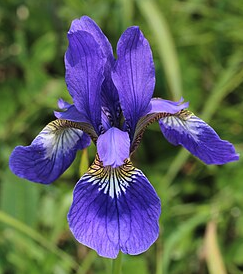


The Iris dataset includes four attributes (features) describing the physical characteristics of iris flowers:

- Sepal length (in centimeters)
- Sepal width (in centimeters)
- Petal length (in centimeters)
- Petal width (in centimeters)

These measurements are used to classify each flower into one of three species:

- Iris setosa
- Iris versicolor
- Iris virginica


### Data Preprocessing



In [2]:
# Load the Iris dataset

X, y = load_iris(return_X_y=True)

# First set aside the test set: 20%
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=random_seed,
    stratify=y
)

# Split the remaining 80% into training and validation sets:
# 75% of development = 60% overall
# 25% of development = 20% overall
X_train, X_val, y_train, y_val = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=random_seed,
    stratify=y_development
)

train_scaler = StandardScaler().fit(X_train)

X_train_scaled = train_scaler.transform(X_train)
X_val_scaled   = train_scaler.transform(X_val)

print(f'X_train.shape = {X_train.shape}')
print(f'X_val.shape   = {X_val.shape}')
print(f'X_test.shape  = {X_test.shape}')

X_train.shape = (90, 4)
X_val.shape   = (30, 4)
X_test.shape  = (30, 4)


#### Important question: Is the target one-hot encoded or integer encoded?

`y_train` has shape `(90,)`, so it is a one-dimensional vector with one target value per sample. Looking at the values, we see integer class labels 0, 1, and 2, so we should use `sparse_categorical_crossentropy`. Let's confirm...

In [3]:
y_train

array([2, 0, 1, 0, 2, 2, 2, 1, 0, 1, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 0, 0,
       2, 1, 2, 2, 2, 2, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 2, 2, 2, 1, 1, 0,
       1, 0, 0, 0, 1, 2, 2, 1, 0, 1, 1, 2, 0, 0, 0, 2, 1, 0, 1, 0, 1, 0,
       1, 2, 2, 0, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 1, 1, 2,
       0, 1])

#### Another important question: Is the dataset balanced (approximately equal number of classes in training set?).

The simplest way to do this for integer labels is to use the `Counter` function, which returns a dictionary giving the frequency of each element in a list. 

In [4]:
Counter(y_train)

Counter({2: 30, 0: 30, 1: 30})

#### Yes,  well balanced!

### Building a Multi-Class Classification Network

Recall that for multi-class classification, we need to use the softmax function to turn the output activations into
a probability distribution, from which we predict the most likely class:

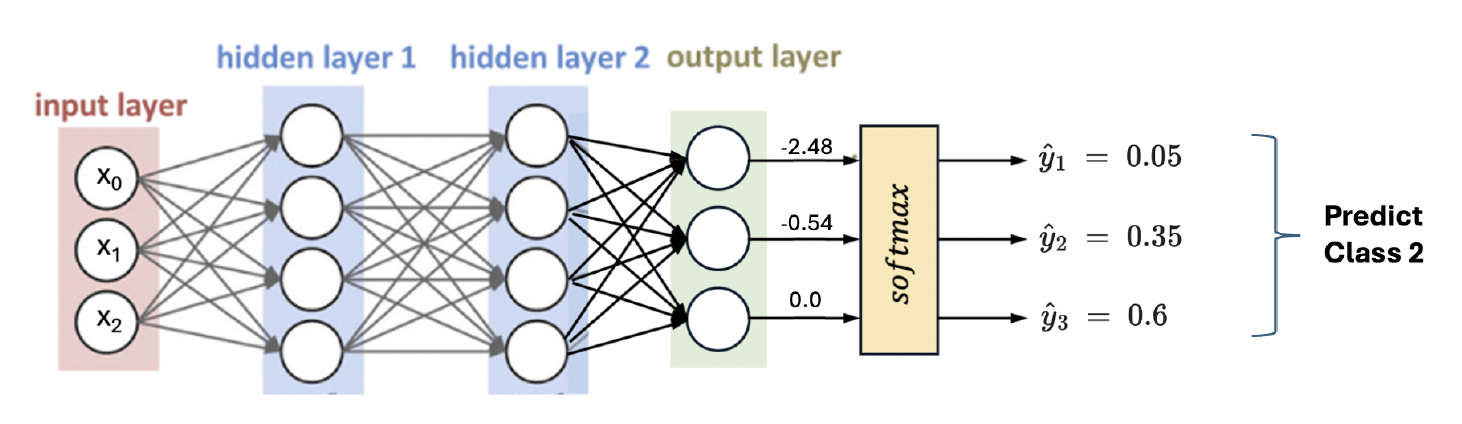

In [5]:
# Here is a simple example of how the softmax function works

activations = np.array([-2.48,-0.54,0.0])

print(softmax(activations))

tf.Tensor([0.05025122 0.34968571 0.60006307], shape=(3,), dtype=float64)


>### Important Digression: What is a tensor?
>
>A **tensor** is like a NumPy array, but with a few important extras. Tensors hold multi-dimensional data just like arrays, but they also:
>
>- Track their **shape** and **data type**
>- Know where they're stored (e.g., **CPU** or **GPU**)
>- Work seamlessly with TensorFlow operations (like layers, loss functions, and gradient computation)
>
>You can convert between NumPy arrays and tensors easily, but tensors are what TensorFlow models expect and use internally.
>
>**Next week we'll explore how to use GPUs in Google Colab and on your own machine.**


## Build the Model

Since this dataset is relatively simple, we'll use a simple network with a single hidden layer with 10 neurons. 

It is an excellent idea to avoid using constants in the input and output layers, since these
can be calculated from the dataset. 

In [6]:
num_features = X_train.shape[1]
print("Number of features:", num_features)

num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

Number of features: 4
Number of classes: 3


In [36]:
# We use Sequential to build a simple classification network from
# a list of layers, and print the summary

width = 10

tf.keras.utils.set_random_seed(random_seed)

iris_model = models.Sequential([
    layers.Input(shape=(num_features,)),             # shape is a tuple (4,) = 1D array of length 4
    layers.Dense(width, activation='relu'),             # small hidden layer
    layers.Dense(num_classes, activation='softmax')  # 3 output classes
])

# Print out layers and stats
iris_model.summary()

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_88 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

### Compile the model: specify the loss, optimizer, and metrics to track

For classification, the loss function depends on how the target labels are encoded:

- Use `sparse_categorical_crossentropy` when the target classes are stored as integers.
- Use `categorical_crossentropy` when the target classes are one-hot encoded.

We will generally use the `Adam` **optimizer** as our default, although many other optimizers are available (see **Appendix One** for a comparison).

Adam's default **learning rate** is **0.001**. The learning rate can have a substantial effect on training, so it is often worth experimenting with different values when tuning a network (see **Appendix Two**).

For longer or more complex training problems, a **learning-rate scheduler** can also be used to change the learning rate automatically during training (see **Appendix Three**).

In [37]:
opt = Adam(learning_rate=0.001)                               # This is the default

iris_model.compile(loss="sparse_categorical_crossentropy",    # Used for classification with integer encoding of targets
                   optimizer=opt,       
                   metrics=["accuracy"]     
                  ) 

### Tuning Learning Rate and Batch Size

The **learning rate** and **mini-batch size** are closely related. During training, the model performs a weight update after each **step** through a mini-batch, using the batch's gradients and the learning rate.

* If you **decrease the batch size**, updates become **more frequent and noisier** because each batch contains fewer samples. In this case, you may need to **lower the learning rate** to maintain stable training.
* If you **increase the batch size**, updates become **less frequent but more stable**, which may allow a **larger learning rate**. Larger batches also require more memory.

In practice:

* **Small batch sizes** (e.g., 16 or 32) produce noisier gradient estimates and can sometimes help generalization, but they may result in more **jagged** loss and validation curves.
* **Larger batch sizes** (e.g., 128 or 256) produce smoother gradient estimates and can make more efficient use of vectorized hardware such as GPUs, especially with large datasets. However, they require more memory and may require adjusting the learning rate.
* **Dataset size matters indirectly:** with very small datasets, there may be little advantage to using large batches, while large datasets can benefit computationally from larger batches. Batch size is still a hyperparameter that should be chosen based on training behavior and available hardware.

A good rule of thumb:

> Start with a batch size of **32 or 64** and the optimizer's default learning rate (for example, `0.001` for `Adam`), then adjust as needed based on training stability, convergence speed, memory use, and computational efficiency.


## Train the model using `fit`

You must specify the training sets, an upper-bound on the number of epochs, the batch size (default is 32, usually works well), and how much information is printed out during training. 

In [38]:
# Set the number of epochs and the batch size for training
epochs = 100
batch_size = 32

iris_history = iris_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=0
)

We will discuss **learning curves** more next week, but we can most easily understand the training phase by looking at the statistics stored in the `history` class.

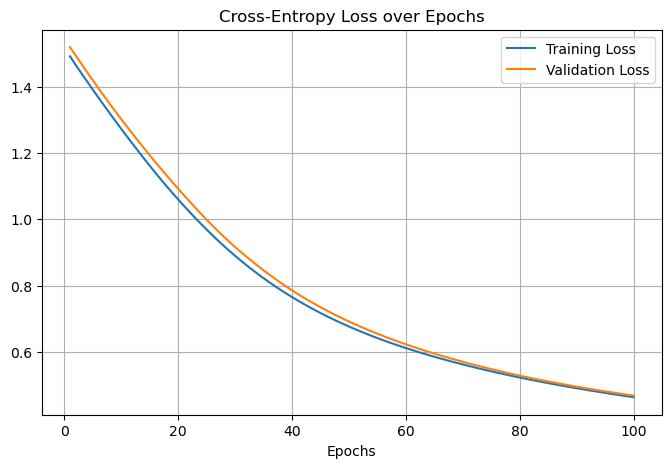

Final Training Loss:   0.4634
Final Validation Loss: 0.4683



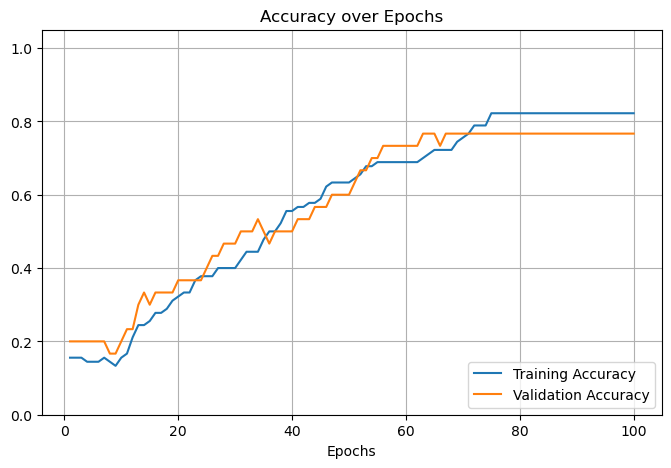

Final Training Accuracy:   0.8222
Final Validation Accuracy: 0.7667



In [39]:
# Print training and validation learning curves

def plot_training(history):
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot cross-entropy loss
    plt.figure(figsize=(8, 5))
    plt.title('Cross-Entropy Loss over Epochs')
    
    plt.plot(
        epochs,
        history.history['loss'],
        label='Training Loss'
    )
    
    plt.plot(
        epochs,
        history.history['val_loss'],
        label='Validation Loss'
    )
    
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid()
    plt.show()
    
    print(f"Final Training Loss:   {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print()
    
    # Plot accuracy
    plt.figure(figsize=(8, 5))
    plt.title('Accuracy over Epochs')
    
    plt.plot(
        epochs,
        history.history['accuracy'],
        label='Training Accuracy'
    )
    
    plt.plot(
        epochs,
        history.history['val_accuracy'],
        label='Validation Accuracy'
    )
    
    plt.xlabel('Epochs')
    plt.ylim(0, 1.05)
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()
    
    print(f"Final Training Accuracy:   {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print()


plot_training(iris_history)

## Refit on the Development Set and Evaluate on the Test Set

In [11]:
# Rebuild the selected model from scratch

tf.keras.utils.set_random_seed(random_seed)

iris_final_model = models.Sequential([
    layers.Input(shape=(num_features,)),             # shape is a tuple (4,) = 1D array of length 4
    layers.Dense(10, activation='relu'),             # small hidden layer
    layers.Dense(num_classes, activation='softmax')  # 3 output classes
])

iris_final_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Scale the complete development set using a scaler
# fit on the development data

development_scaler = StandardScaler().fit(X_development)

X_development_scaled = development_scaler.transform(X_development)
X_test_scaled = development_scaler.transform(X_test)

iris_final_model.fit(
    X_development_scaled,
    y_development,
    epochs=epochs,
    batch_size=batch_size,
    verbose=0
)

In [13]:
test_loss, test_accuracy = iris_final_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss:     0.4572
Test Accuracy: 0.7667


## Make Predictions

We'll just extract the first two samples from the test set to show how to do predictions. 

Note that `predict` expects a 2D array, i.e., a list of samples, and will return an array of the softmax outputs; you'll need to extract the index of the largest probability to get the predicted class. 

In [14]:
samples = X_test_scaled[:2]

print(samples)
print()

y_pred = iris_final_model.predict(samples, verbose=0)
print(y_pred)
print()

y_pred_class = np.argmax(y_pred, axis=1)

print(f"True labels: {y_test[:2]}")
print(f"Predicted:   {y_pred_class}")

[[-1.72156775 -0.10821272 -1.40250384 -1.32327558]
 [ 0.30848902 -0.10821272  0.64163131  0.78343181]]

[[0.9741599  0.01753596 0.00830409]
 [0.05676255 0.37920788 0.5640295 ]]

True labels: [0 2]
Predicted:   [0 2]


## Appendix One: Comparing Optimizers

An optimizer is a model-design choice, so we should compare optimizers using the
**validation set**, not the test set.

Each model below is trained on the same training data, starting from the same
initial random weights. After each epoch, we measure its performance on the
validation set. This allows us to compare the optimizers without using the
test data, which we reserve for the final evaluation.

Training with SGD...
Training with Adam...
Training with RMSprop...
Training with Adagrad...


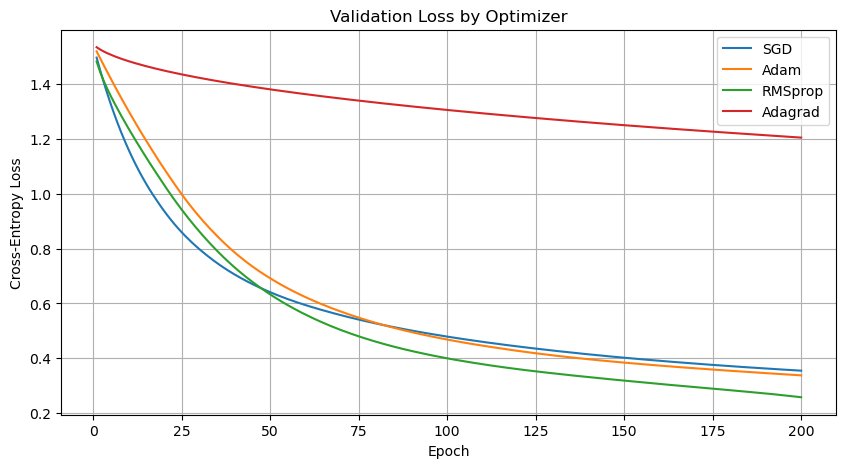

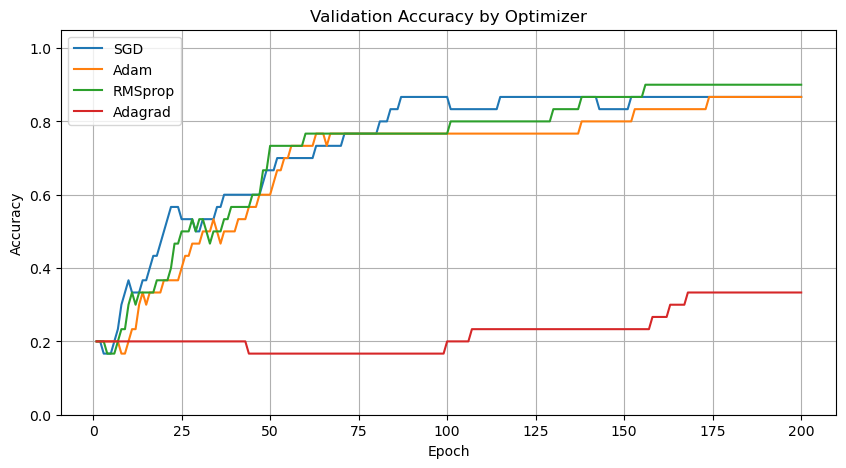

In [20]:
# Compare several optimizers using validation performance

optimizers_to_test = {
    "SGD":     tf.keras.optimizers.SGD(learning_rate=0.01),
    "Adam":    tf.keras.optimizers.Adam(learning_rate=0.001),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.001),
}

appendix_epochs = 200

val_loss_dict = {}
val_acc_dict = {}

for name, opt in optimizers_to_test.items():

    print(f"Training with {name}...")

    # Start each comparison from freshly initialized weights
    tf.keras.utils.set_random_seed(random_seed)

    # Fresh model for each run
    model = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(10, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=appendix_epochs,
        batch_size=batch_size,
        verbose=0
    )

    # Save validation results for comparison
    val_loss_dict[name] = history.history['val_loss']
    val_acc_dict[name] = history.history['val_accuracy']


# Plot validation loss
plt.figure(figsize=(10, 5))

for name, losses in val_loss_dict.items():
    plt.plot(
        range(1, appendix_epochs + 1),
        losses,
        label=name
    )

plt.title("Validation Loss by Optimizer")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()


# Plot validation accuracy
plt.figure(figsize=(10, 5))

for name, acc in val_acc_dict.items():
    plt.plot(
        range(1, appendix_epochs + 1),
        acc,
        label=name
    )

plt.title("Validation Accuracy by Optimizer")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

### Appendix Two: Comparing Learning Rates

`Adam` is the common choice for a wide variety of tasks. Let's see how it performs with different learning rates. 
In general, lower learning rates combined with more training epochs can lead to better convergence—but only up to a point. Be mindful of diminishing returns, where additional training yields little to no improvement.

  0%|          | 0/5 [00:00<?, ?it/s]

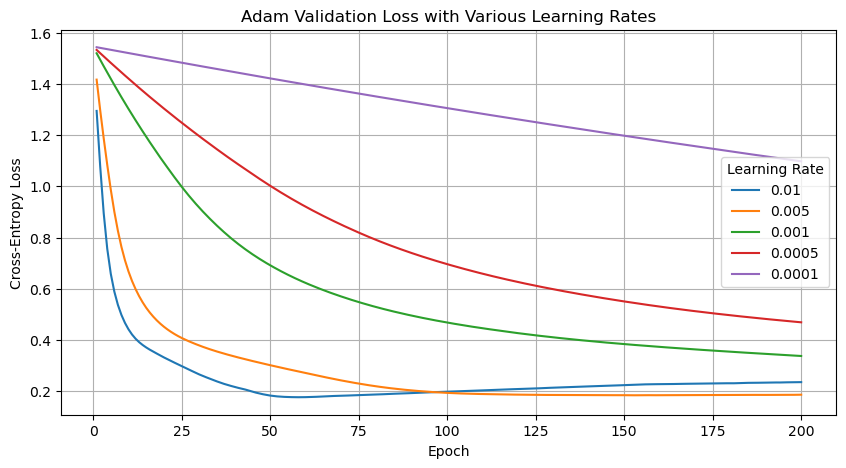

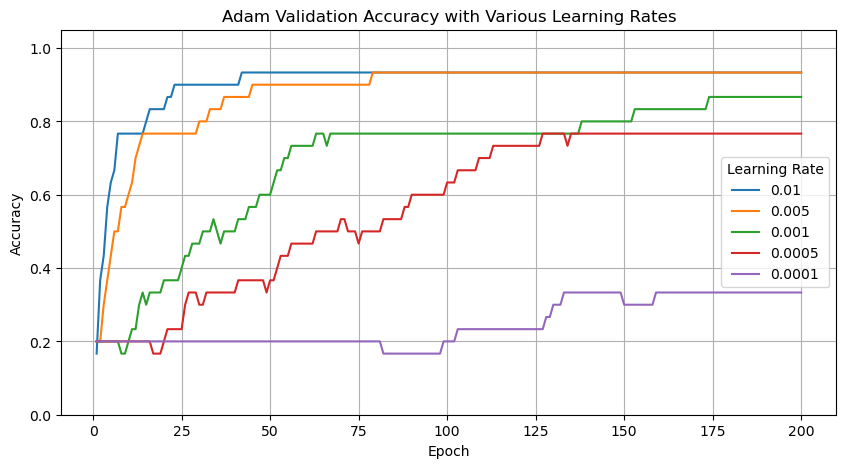

In [21]:
# Compare Adam with several learning rates using validation performance

learning_rates = [0.01, 0.005, 0.001, 0.0005, 0.0001]

val_loss_dict = {}
val_acc_dict = {}

for lr in tqdm(learning_rates):

    # Start each comparison from the same random initialization
    tf.keras.utils.set_random_seed(random_seed)

    # Fresh model for each run
    model = models.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(10, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=appendix_epochs,
        batch_size=batch_size,
        verbose=0
    )

    val_loss_dict[lr] = history.history['val_loss']
    val_acc_dict[lr] = history.history['val_accuracy']


# Plot validation loss
plt.figure(figsize=(10, 5))

for lr, losses in val_loss_dict.items():
    plt.plot(
        range(1, appendix_epochs + 1),
        losses,
        label=lr
    )

plt.title("Adam Validation Loss with Various Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend(title="Learning Rate")
plt.grid(True)
plt.show()


# Plot validation accuracy
plt.figure(figsize=(10, 5))

for lr, acc in val_acc_dict.items():
    plt.plot(
        range(1, appendix_epochs + 1),
        acc,
        label=lr
    )

plt.title("Adam Validation Accuracy with Various Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend(title="Learning Rate")
plt.grid(True)
plt.show()

## Appendix Three: Comparing Learning-Rate Schedulers

So far, we have used a fixed learning rate during training. Another option is to use a
**learning-rate scheduler**, which changes the learning rate automatically as training proceeds.

A common strategy is to begin with a relatively large learning rate so that the model can make
substantial updates early in training, then gradually reduce the learning rate so that later
updates become smaller and more precise.

TensorFlow provides several built-in learning-rate schedules. In this appendix, we compare:

* a **constant learning rate**;
* **step decay**, which reduces the learning rate at specified points during training;
* **exponential decay**, which reduces the learning rate smoothly over time;
* **cosine decay**, which gradually reduces the learning rate following a cosine-shaped curve.


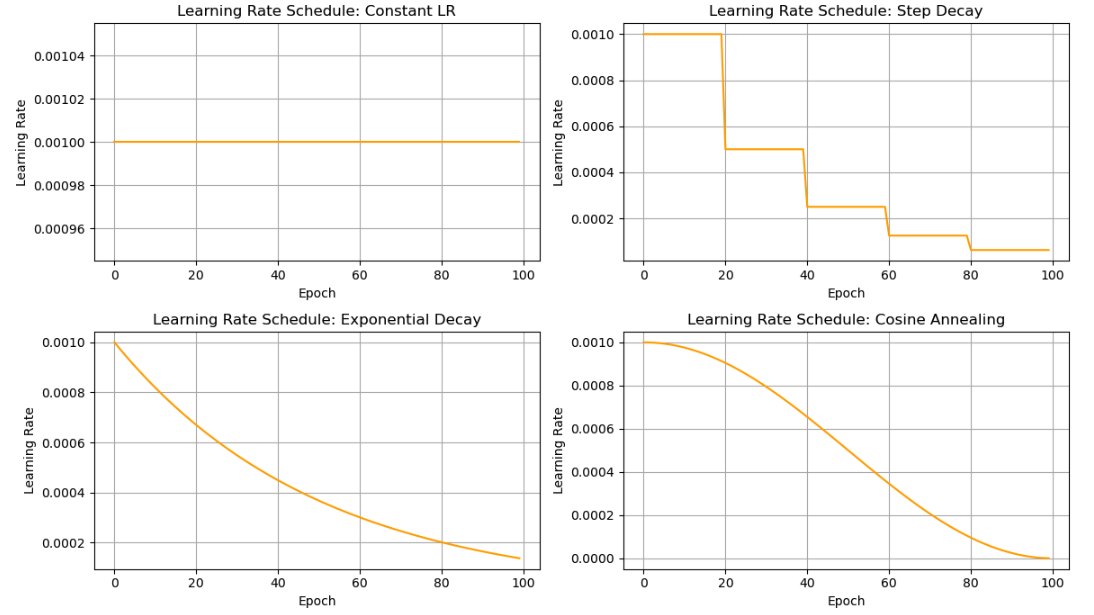


Because the choice of learning-rate schedule is a training hyperparameter, we compare these
methods using the **validation set**, while keeping the test set untouched for final evaluation.

The following experiment uses the same model architecture, training data, batch size, and
initial random weights for each schedule so that the main difference is the learning-rate strategy.

Training with Constant...
Training with Step Decay...
Training with Exponential Decay...
Training with Cosine Decay...


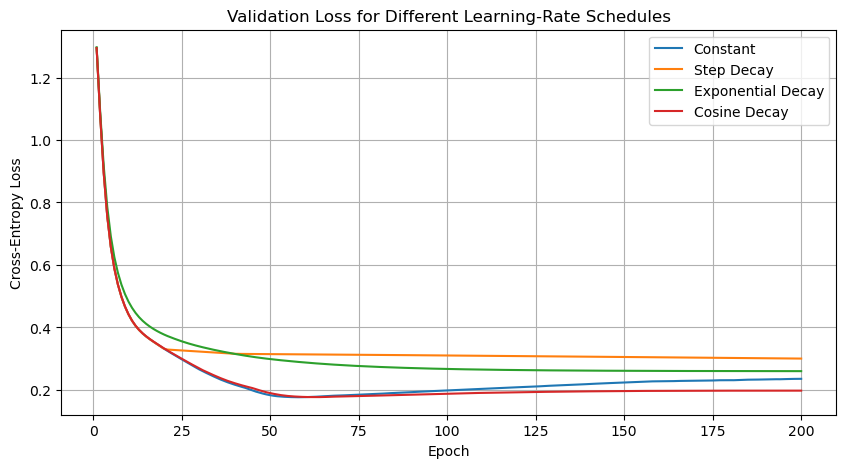

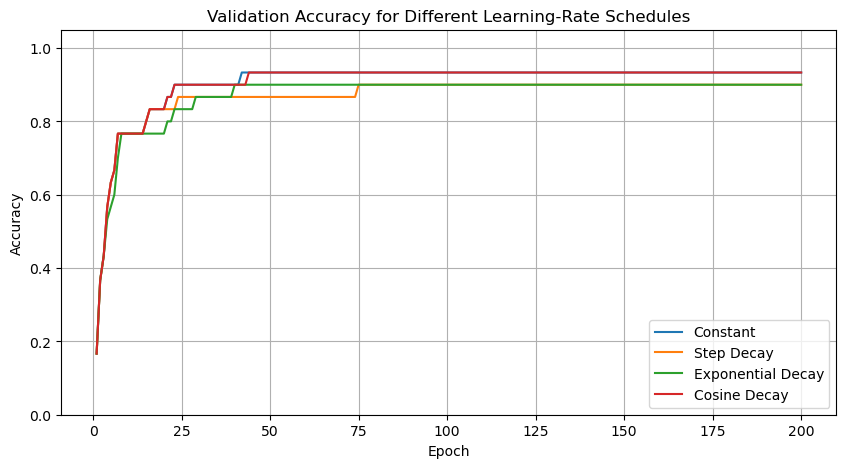

In [23]:
# Compare learning-rate schedules using validation performance

# Training settings
steps_per_epoch = int(np.ceil(len  / batch_size))
total_steps = appendix_epochs * steps_per_epoch
initial_lr = 0.01

# Learning-rate schedules
lr_schedulers = {
    "Constant": initial_lr,

    "Step Decay": PiecewiseConstantDecay(
        boundaries=[
            20 * steps_per_epoch,
            40 * steps_per_epoch
        ],
        values=[
            initial_lr,
            initial_lr * 0.1,
            initial_lr * 0.01
        ]
    ),

    "Exponential Decay": ExponentialDecay(
        initial_learning_rate=initial_lr,
        decay_steps=20 * steps_per_epoch,
        decay_rate=0.5,
        staircase=False
    ),

    "Cosine Decay": CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=total_steps
    )
}

# Store histories
history_dict = {}

# Train one model for each scheduler
for name, lr_schedule in lr_schedulers.items():

    print(f"Training with {name}...")

    # Start each comparison from the same random initialization
    tf.keras.utils.set_random_seed(random_seed)

    # Fresh model for each run
    model = models.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(10, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    optimizer = Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        batch_size=batch_size,
        epochs=appendix_epochs,
        verbose=0
    )

    history_dict[name] = history.history


# Plot validation loss
plt.figure(figsize=(10, 5))

for name, hist in history_dict.items():
    plt.plot(
        range(1, appendix_epochs + 1),
        hist['val_loss'],
        label=name
    )

plt.title("Validation Loss for Different Learning-Rate Schedules")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()


# Plot validation accuracy
plt.figure(figsize=(10, 5))

for name, hist in history_dict.items():
    plt.plot(
        range(1, appendix_epochs + 1),
        hist['val_accuracy'],
        label=name
    )

plt.title("Validation Accuracy for Different Learning-Rate Schedules")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()